# FOL-Triage: screening a three-layer logic-translation checker

This notebook runs **FOL-Triage**, a checker that scores whether a candidate first-order-logic (FOL) formula is faithful to its natural-language sentence. It needs no gold formula and no ontology. The checker has three layers:

| Layer | What it checks | Cost |
|---|---|---|
| **L1 `fol_lint`** | Checks the formula only, never the text: patterns that are unlikely to render any English sentence, such as `∃x(A→B)`, `∀x(A∧B)`, free or dangling variables, arity clashes, and vacuous or trivial formulas (checked with z3). | CPU |
| **L2-bow `content_accounting`** | Bag-of-words accounting: predicates that no word in the text supports (**ADD**), and the share of text content words that no predicate carries (**DROP**). | CPU |
| **L2-role `role_accounting`** | Role-aware accounting: spaCy finds each word's dependency role (condition, asserted or exception, with negation). That role must agree with the z3 monotonicity of the predicate the word aligns to. Also checks the argument order of binary predicates. | CPU |
| **L3 `role_questionnaire` + `l3_compare`** | A small LLM (`gemini-2.5-flash-lite`) reads **only the sentence** and fills a frozen role schema. The formula side of the same schema is computed **exactly** with z3. L3 scores how much the two disagree. | ≈$0.0002 per item |

The layers are combined by a **fused logistic model**, trained on track H (curated original → corrected gold) with a guard against sentence overlap. The fused model was frozen in `prereg.json` before any track-L label was joined. On the full screen (753 track-L outputs from Logic-LM gpt-3.5/gpt-4/davinci-003 on FOLIO-dev, labelled against corrected gold), the primary result was a **fused AUROC of 0.759** [0.695, 0.825] for ERROR vs CORRECT. The single layers scored: L2-bow 0.737, L3 0.756, L2-role 0.557 and L1 0.508.

This notebook is the original `method.py` (stages 4–7), split into cells with only minimal changes:
* It loads the input files from `mini_demo_data.json` rather than the full workspace. The subset has 100 items: 50 track L, 25 track H and 25 HREF.
* It turns `main()` into top-level cells and replaces `asyncio.run(...)` with top-level `await`, because Jupyter already runs an event loop.
* LLM answers come from the original run's **response cache**, which is bundled in the data file, so no API key is needed and the demo costs $0. Set `LLM_LIVE = "1"` and `OPENROUTER_API_KEY` to query OpenRouter live.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, loguru, spaCy English model -- NOT on Colab, always install
_pip('z3-solver==5.1.0.0', 'loguru==0.7.3')
_pip('--no-deps', 'https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl')

# numpy, pandas, sklearn, scipy, matplotlib, nltk, spacy, aiohttp -- pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0',
         'nltk==3.9.1', 'spacy==3.8.11', 'aiohttp==3.14.3')

## Imports
This is the original import block of `method.py`, plus matplotlib for the final plots. L2-bow uses the WordNet corpus from NLTK, so it is downloaded here.

In [2]:
from __future__ import annotations

import asyncio
import hashlib
import json
import math
import pickle
import resource
import sys
import time
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
from loguru import logger

# notebook additions
import os
import nltk
import matplotlib.pyplot as plt
nltk.download("wordnet", quiet=True)  # content_accounting.py (L2-bow) expands words with WordNet lemmas

True

## Data loading helper
The helper loads `mini_demo_data.json` from GitHub. If that fails (for example before the files are pushed), it falls back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_qck1d05BqxkX/round-1/experiment-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print({k: len(v) for k, v in data.items() if k != "description"})

FOL-Triage demo subset of the frozen shared screen: 50 track-L items (Logic-LM FOLIO-dev outputs of gpt-3.5-turbo / gpt-4 / text-davinci-003; 18 ERROR, 18 CORRECT, 8 UNCERTAIN, 6 UNPARSEABLE), 25 track-H items (curated original gold; 12 fusion positives interleaved with CORRECT), 25 HREF items (corrected gold as its own candidate), the 90 invariance-rewrite rows of the chosen track-L items, the screen metadata, the cached LLM answers those items need, and the experiment's helper modules (src/*.py).
{'screen_items': 75, 'href_items': 25, 'invariance_set': 90, 'screen_meta': 16, 'llm_cache': 335, 'support_code': 10}


## Materialise the helper modules and the LLM response cache
`method.py` imports the experiment's helper modules from `src/`:

| Module | Contents |
|---|---|
| `fol.py` | FOL parser and z3 bridge |
| `fol_triage.py` | The released L1/L2/L3 functions |
| `lint_smells.py` | Formula-smell detectors used by L1 |
| `content_accounting.py` | Bag-of-words accounting used by L2-bow |
| `pipeline.py` | Cached CPU layers and asynchronous LLM stages |
| `llm.py` | OpenRouter client and read-only cache |
| `disguise.py` | Nonce-disguise contamination control |
| `analysis.py` | Stage 7: labels are joined and metrics computed |
| `output.py` | Writes `method_out.json` |
| `screen.py` | Text normaliser |

The modules travel **verbatim** inside `mini_demo_data.json`, and this cell writes them back to `src/`. It also writes the cached LLM answers to `cache/llm_cache.jsonl`, because `llm.CachedLLM` serves questionnaire answers from that file.

`screen_items.json` and `screen_meta.json` are also written to disk, because `analysis.py`, the only stage that reads labels, loads them from the working directory.

In [5]:
ROOT = Path.cwd()          # original: Path(__file__).resolve().parent
(ROOT / "src").mkdir(exist_ok=True)
for fname, src_text in data["support_code"].items():
    (ROOT / "src" / fname).write_text(src_text)
(ROOT / "cache").mkdir(exist_ok=True)
with (ROOT / "cache" / "llm_cache.jsonl").open("w") as fh:
    for rec in data["llm_cache"]:
        fh.write(json.dumps(rec, ensure_ascii=False) + "\n")
(ROOT / "screen_items.json").write_text(json.dumps(data["screen_items"], ensure_ascii=False, indent=1))
(ROOT / "screen_meta.json").write_text(json.dumps(data["screen_meta"], ensure_ascii=False, indent=1))
print(sorted(p.name for p in (ROOT / "src").glob("*.py")), "|", len(data["llm_cache"]), "cached LLM answers")

['analysis.py', 'content_accounting.py', 'disguise.py', 'fol.py', 'fol_triage.py', 'lint_smells.py', 'llm.py', 'output.py', 'pipeline.py', 'screen.py'] | 335 cached LLM answers


## Configuration
These are the tunable parameters:

* **`DRY`**: the original script's dry-run switch. `DRY = N` keeps the first N track-L items (sorted by `item_id`), the first N track-H items and the first N HREF items. It also writes to `results_dry/` and uses B = 200 bootstrap resamples. `DRY = 0` uses every item in the data file. In the original, `DRY = 0` meant the full 1,055-item screen; here the file holds the 100-item demo subset.
* **`B_BOOT`**: the number of cluster-bootstrap resamples used for the AUROC confidence intervals when `DRY = 0`. The original value is 2000.
* **`LLM_LIVE`**: `"0"` serves every LLM call from the bundled cache. `"1"` calls OpenRouter live and needs `OPENROUTER_API_KEY`. On a cache miss, the pipeline records `L3_MISSING` coverage rather than crashing.

In [6]:
DRY = 0          # original: int(os.environ.get("DRY", "0")); 0 = all items in the data file (orig. full screen = 1055 items)
B_BOOT = 2000      # cluster-bootstrap resamples for AUROC CIs (original: 2000)
LLM_LIVE = "0"    # "0" = read LLM answers from the bundled cache; "1" = live OpenRouter calls (needs OPENROUTER_API_KEY)
os.environ["LLM_LIVE"] = LLM_LIVE

## Setup: paths, logging, helper-module imports and method constants
This setup code is unchanged from the top of `method.py`, apart from the notebook `ROOT` and the `DRY` variable set in the configuration cell. It pins:
* the L3 models: the primary model, a second robustness model and the local fallback;
* the 7 fusion features;
* the logistic-regression C;
* the prevalences used for re-weighted precision.

In [7]:
SRC = ROOT / "src"
sys.path.insert(0, str(SRC))
sys.setrecursionlimit(10000)
(ROOT / "logs").mkdir(exist_ok=True)
(ROOT / "results").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")
resource.setrlimit(resource.RLIMIT_AS, (20 * 1024**3, 20 * 1024**3))

from pipeline import (scoring_view, run_cpu_layers, run_questionnaires, run_decomposed, run_profiles,  # noqa: E402
                      prof_from_json, sha1, ledger_total, safe_log_words)
from screen import norm  # noqa: E402
import fol_triage as FT  # noqa: E402

# Primary L3 model = the planned google/gemini-2.5-flash-lite (OpenRouter). Between 13:30 and ~15:00 UTC the shared key
# was at its $50 daily limit; during the outage L3 ran on a local llama.cpp model, whose complete answers are kept as an
# extra robustness row (LOCAL). The key was restored before prereg.json was written, so the planned design is restored.
PRIMARY = "google/gemini-2.5-flash-lite"
SECOND = "qwen/qwen3-30b-a3b-instruct-2507"  # planned 2nd cheap model (robustness row on HREF)
LOCAL = "local/qwen2.5-1.5b-instruct-q4_k_m"  # outage fallback, cache-only robustness row
FEATS = ["l1_any", "n_smells", "bow_uncarried", "bow_n_unanch", "role_count", "l3_score", "log_words"]
FUSION_C = 1.0
PREVALENCES = [0.10, 0.25]
# B_BOOT is set in the config cell (original: 2000)
# DRY is set in the config cell  (original: int(os.environ.get("DRY", "0")))
RES = ROOT / ("results_dry" if DRY else "results")
RES.mkdir(exist_ok=True)
PREREG = RES / "prereg.json" if DRY else ROOT / "prereg.json"


def sha256f(p: Path) -> str:
    return hashlib.sha256(p.read_bytes()).hexdigest()


def load_json(p):
    return json.loads(Path(p).read_text())

## Feature assembly: `layer_row` and `fvec`
`layer_row(text, fol, ...)` collects every layer's output for one (text, formula) pair:

* **L1**: smell codes.
* **L2-bow**: the uncarried share and the unanchored predicates.
* **L2-role**: the count of role mismatches.
* **L3**: the per-field mismatch between the text-only questionnaire and the exact z3 formula profile, weighted into `l3_score` over the *gated* fields.

A formula that does not parse gets `parse_ok=False` and no features, so it is counted, not dropped. `fvec` extracts the 7 fusion features.

In [8]:
# ======================================================================================= feature assembly
def layer_row(text: str, fol: str, cpu: dict, q: dict | None, gated: list[str], l3_impute: float,
              prof_override: dict | None = None, exact: bool = False) -> dict:
    """All layer outputs + fusion features for one (text, fol). Unparseable -> parse_ok False (no features)."""
    r = {"parse_ok": bool(cpu.get("parse_ok")), "cpu_status": cpu.get("status"), "log_words": safe_log_words(text)}
    if not r["parse_ok"] or cpu.get("status") != "OK":
        r.update(coverage_status="UNPARSEABLE" if not r["parse_ok"] else cpu.get("status"))
        return r
    l1 = cpu["l1"]
    r.update(l1_codes=l1["codes"], l1_any=int(bool(l1["codes"])), n_smells=len(l1["codes"]), z3_unknown=l1["z3_unknown"])
    b = cpu.get("bow")
    r.update(bow_uncarried=b["uncarried_frac"] if b else 0.0, bow_n_unanch=b["n_unanchored"] if b else 0,
             bow_flag=int(b["flag"]) if b else 0, bow_unanchored=b["unanchored_preds"] if b else [],
             bow_ok=b is not None)
    ro = cpu.get("role")
    r.update(role_count=ro["count"] if ro else 0, role_flag=int(ro["flag"]) if ro else 0,
             role_codes=ro["codes"] if ro else [], role_ok=ro is not None,
             role_n_words=ro["n_role_words"] if ro else 0, role_n_resolved=ro["n_resolved"] if ro else 0)
    prof = prof_override if prof_override is not None else prof_from_json(cpu.get("profile"))
    status = "OK"
    if q is None or q.get("q") is None:
        status = q.get("coverage_status", "L3_FAIL") if q else "L3_MISSING"
    if status == "OK" and prof:
        cmp = FT.l3_compare(q["q"], prof, exact=exact)
        r["l3"] = {k: v for k, v in cmp.items() if k != "extra_keys"}
        r["l3_score"] = FT.l3_score(cmp, gated)
        r["l3_ok"] = True
    else:
        r["l3"] = None
        r["l3_score"] = l3_impute
        r["l3_ok"] = False
    r["coverage_status"] = "OK" if (status == "OK" and r["bow_ok"] and r["role_ok"] and not l1["z3_unknown"]) else \
        (status if status != "OK" else ("Z3_UNKNOWN" if l1["z3_unknown"] else "L2_FAIL"))
    return r


def fvec(r: dict) -> list[float]:
    return [float(r.get(f, 0.0) or 0.0) for f in FEATS]

## Calibration helpers
* **`wilson`**: the Wilson 95% interval for a proportion.
* **`field_accuracy`**: for formulas **known to be correct** (HREF), how often each L3 questionnaire field agrees with the exact formula profile. This is the per-field *gate*: fields below 0.70 are excluded from `l3_score`, and fields between 0.70 and 0.85 are flagged.
* **`fit_fusion`**: `StandardScaler` followed by a class-balanced logistic regression, with out-of-fold predictions from `GroupKFold(5)` grouped by normalised sentence.
* **`coefs`**: reads back the fitted coefficients.

In [9]:
# ======================================================================================= calibration helpers
def wilson(k: int, n: int, z: float = 1.96):
    if n == 0:
        return [None, None]
    p = k / n
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return [round(max(0.0, c - h), 4), round(min(1.0, c + h), 4)]


def field_accuracy(rows: list[dict]) -> dict:
    """Pooled per-field agreement of questionnaire vs formula profile over aligned concepts (known-correct formulas)."""
    agg = defaultdict(lambda: [0, 0])
    ri = []
    n_conc = n_al = 0
    for r in rows:
        c = r.get("l3")
        if not c:
            continue
        n_conc += c["n_concepts"]; n_al += c["n_aligned"]
        for f, nk in (("mm_role", "n_role"), ("mm_force", "n_force"), ("mm_order", "n_order"),
                      ("mm_exception", "n_exc")):
            if c[f] is not None and c[nk]:
                agg[f][0] += round((1 - c[f]) * c[nk]); agg[f][1] += c[nk]
        if c["mm_claims"] is not None:
            ri.append(1 - c["mm_claims"])
        if c["n_need"]:
            agg["missing_frac"][0] += c["n_need"] - c["n_missing"]; agg["missing_frac"][1] += c["n_need"]
        if c["n_pred_eval"]:
            agg["extra_frac"][0] += c["n_pred_eval"] - c["n_extra"]; agg["extra_frac"][1] += c["n_pred_eval"]
    out = {}
    for f, (k, n) in agg.items():
        out[f] = {"acc": round(k / n, 4) if n else None, "n": n, "wilson95": wilson(k, n)}
    out["mm_claims"] = {"acc": round(float(np.mean(ri)), 4) if ri else None, "n": len(ri),
                        "wilson95": wilson(int(round(sum(ri))), len(ri)) if ri else [None, None]}
    out["alignment_rate"] = round(n_al / n_conc, 4) if n_conc else None
    out["n_items"] = sum(1 for r in rows if r.get("l3"))
    return out


def fit_fusion(X, y, groups, seed: int = 0):
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import GroupKFold
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    X, y, groups = np.asarray(X, float), np.asarray(y, int), np.asarray(groups)
    oof = np.zeros(len(y))
    for tr, te in GroupKFold(n_splits=5).split(X, y, groups):
        m = make_pipeline(StandardScaler(), LogisticRegression(C=FUSION_C, class_weight="balanced",
                                                               max_iter=2000))
        m.fit(X[tr], y[tr])
        oof[te] = m.predict_proba(X[te])[:, 1]
    full = make_pipeline(StandardScaler(), LogisticRegression(C=FUSION_C, class_weight="balanced",
                                                              max_iter=2000))
    full.fit(X, y)
    return full, oof


def coefs(m) -> dict:
    lr = m.steps[-1][1]
    return {"intercept": float(lr.intercept_[0]), **{f: float(c) for f, c in zip(FEATS, lr.coef_[0])}}

## Main, part 1: load the screen and hide the track-L labels
This cell starts the body of `main()`, now run as top-level cells. The file reads are replaced by the loaded `data`.

Only **track-H** labels are visible to calibration. `scoring_view` strips `label`, `auto_class` and `repair_ops` from every item, and asserts that they are gone, so the scoring stages cannot see track-L labels.

In [10]:
t_start = time.time()
items_full = data["screen_items"]      # original: load_json(ROOT / "screen_items.json")
href = data["href_items"]              # original: load_json(ROOT / "href_items.json")
inv = data["invariance_set"]           # original: load_json(ROOT / "invariance_set.json")
meta = data["screen_meta"]             # original: load_json(ROOT / "screen_meta.json")
# --- label access: ONLY track H labels are visible to calibration; track-L labels are joined in analysis.py
h_lab = {x["item_id"]: (x["label"], x["auto_class"]) for x in items_full if x["track"] == "H"}
if DRY:
    keep_ids = {x["item_id"] for x in sorted([x for x in items_full if x["track"] == "L"], key=lambda x: x["item_id"])[:DRY]}
    keep_ids |= {x["item_id"] for x in [x for x in items_full if x["track"] == "H"][:DRY]}
    items_full = [x for x in items_full if x["item_id"] in keep_ids]
    href = href[:DRY]
    inv = [r for r in inv if r["item_id"] in keep_ids]
items = scoring_view(items_full)
del items_full
H = [x for x in items if x["track"] == "H"]
L = [x for x in items if x["track"] == "L"]
text_of = {x["item_id"]: x["text"] for x in items}
logger.info(f"screen: H={len(H)} L={len(L)} HREF={len(href)} invariance rows={len(inv)}")

12:47:17|INFO   |screen: H=25 L=50 HREF=25 invariance rows=90


## Stage 3: CPU layers (L1, L2-bow, L2-role, exact z3 formula profile)
For every (text, formula) pair, this stage runs the following in a spawn process pool with a hard 120 s timeout per pair:

1. Parse the formula.
2. `fol_lint` (L1).
3. `content_accounting` (L2-bow).
4. `formula_role_profile`, the exact z3 monotonicity and role of each predicate.
5. `role_accounting` (L2-role).

The pairs are the screen items, the HREF items, and the meaning-preserving rewrites of the invariance set. Results are cached in `cache/cpu_layers.jsonl`.

In [11]:
# --------------------------------------------------------------------------- STAGE 3: CPU layers (cached)
pairs = [(x["text"], x["candidate_fol"]) for x in items + href]
pairs += [(text_of[r["item_id"]], r["rewritten_fol"]) for r in inv if r["rewritten_fol"]]
cpu = run_cpu_layers(pairs)
cpu_of = lambda t, f: cpu[sha1(f"{t}|{f}")]  # noqa: E731

12:47:17|INFO   |cpu_layers: 122 unique pairs, 122 uncached


12:47:36|INFO   |  cpu_layers 100/122 (19s)


## Stage 4: pre-registration
The pre-registration is written **before** any track-L label is joined to a score. It freezes:
* code hashes;
* layer thresholds;
* L2-role lexicons;
* the L3 prompt, schema and model;
* the fusion design, including the sentence-leak guard;
* the primary and secondary analyses;
* the bootstrap settings;
* the gates: AUROC ≥ 0.65, coverage ≥ 0.90, rewrite false-alarm rate ≤ 0.10, cost ≤ $0.002 per item.

In [12]:
# --------------------------------------------------------------------------- STAGE 4: pre-registration
if not PREREG.exists():
    pre = {
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "note": "written BEFORE any track-L label is joined to any score; analysis.py is the only label join",
        "code_sha256": {p.name: sha256f(p) for p in sorted(SRC.glob("*.py"))},  # original also hashed method.py itself
        "screen_labels_sha256": meta["labels_sha256"],
        "PRECEDENCE_FIX": "fol.py PREC iff1 imp2 xor3 or3 and4 (iter-3 had xor=1 below ->); T0: exactly 3 track-H "
                          "COMPOUND -> EQUIV",
        "L1_smells": ["EX_IMP", "ALL_AND", "IFF_RESTR", "GLUE", "FREE", "VACUOUS", "TRIVIAL", "ARITY", "DANGLING"],
        "L1_threshold": "any smell",
        "L2_bow_threshold": "n_unanchored >= 1 or uncarried_frac > 0.34 (iter-3)",
        "L2_role_threshold": "cond_in_up + assert_in_down + pol_flip + slot_swap + exc_wrong >= 1",
        "L2_role_lexicons": {"COND_MARKS": FT.COND_MARKS, "EXC_MARKS": FT.EXC_MARKS,
                             "GENERIC_DETS": sorted(FT.GENERIC_DETS), "GENERIC_PRON": sorted(FT.GENERIC_PRON),
                             "NEG_WORDS": sorted(FT.NEG_WORDS)},
        "L3_model_primary": PRIMARY, "L3_model_robustness": SECOND, "L3_temperature": 0.0,
        "L3_model_local_row": LOCAL,
        "L3_model_note": "OpenRouter shared key hit its $50 daily limit 13:30-~15:00 UTC 2026-09-23; meanwhile all "
                         "421 L3 sentences were answered by local Qwen2.5-1.5B-Instruct Q4_K_M (llama.cpp, CPU, "
                         "JSON-schema grammar). The key was restored before this prereg, so the planned primary "
                         "(flash-lite) is used; the local answers are an extra robustness row. The prompt carries a "
                         "'compact on ONE line' instruction added for the local model (kept for all models).",
        "L3_schema": FT.L3_SCHEMA_TEXT, "L3_prompt_sha256": hashlib.sha256(FT.L3_SYSTEM.encode()).hexdigest(),
        "L3_prompt": FT.L3_SYSTEM,
        "L3_fields": FT.L3_FIELDS,
        "L3_field_gate": {"target": 0.85, "exclude_below": 0.70, "flag_between": [0.70, 0.85],
                          "measured_on": "HREF (corrected gold as candidate), primary model"},
        "L3_threshold": "90th percentile of l3_score on HREF (10% FA on known negatives by construction)",
        "L3_alignment": "overlap coefficient >= 0.5 of phrase content words vs predicate-name words (stem/WordNet), "
                        "Jaccard tie-break (departure from plan's Jaccard>=0.5: single-token predicate names vs "
                        "multi-word phrases)",
        "fusion_features": FEATS, "fusion_model": f"StandardScaler + LogisticRegression(l2, C={FUSION_C}, "
                                                    "class_weight=balanced)",
        "fusion_training": "positives = track-H ERROR + COMPOUND (non-ambiguous); negatives = track-H CORRECT + HREF; "
                           "GroupKFold(5) by normalised sentence -> OOF",
        "fusion_primary_for_L": "refit on H+HREF rows whose norm(text) does NOT occur in track L (sentence-leak guard)",
        "fusion_secondary": ["refit on all H+HREF", "within-L GroupKFold cross-fit (analysis only)"],
        "fused_threshold": "value giving 10% FA on HREF + track-H CORRECT (OOF)",
        "primary_analysis": "track L, label in {CORRECT, ERROR}",
        "secondary_analyses": ["ERROR u UNCERTAIN(COMPOUND) vs CORRECT",
                               "ERROR minus pure ADD+DROP (atom substitution; likely vocabulary artefact) vs CORRECT "
                               "[added after inspecting the screen's label distribution, before any score was joined]",
                               "track H reported separately; READING_CHOICE never pooled"],
        "bootstrap": {"B": B_BOOT, "cluster": "normalised sentence", "seed": 0},
        "prevalences_for_reweighted_precision": PREVALENCES,
        "strata": ["len_bin", "n_quant", "depth", "n_conditions", "exception"],
        "strata_untestable_rule": "<50 errors or <50 correct -> descriptive only",
        "gates": {"coverage": ">= 0.90", "rewrite_FA_per_family": "<= 0.10", "cost_per_item_usd": "<= 0.002",
                  "AUROC": ">= 0.65"},
    }
    PREREG.write_text(json.dumps(pre, ensure_ascii=False, indent=1))
    logger.info("prereg.json written (stage 4)")
pre = load_json(PREREG)

12:47:38|INFO   |prereg.json written (stage 4)


## Stage 5a: L3 questionnaires and the per-field gate on HREF
The primary model answers the **text-only** role questionnaire for every sentence. On HREF, where the corrected gold is used as the candidate and is therefore known to be correct, `field_accuracy` measures how often each questionnaire field agrees with the exact z3 profile of the formula. That result decides which fields are gated into `l3_score`.

`asyncio.run(...)` from the script is replaced by top-level `await`, because Jupyter already runs an event loop.

In [13]:
# --------------------------------------------------------------------------- STAGE 5: calibration (H + HREF)
hh_texts = list(dict.fromkeys([x["text"] for x in H] + [h["text"] for h in href]))
l_texts = list(dict.fromkeys(x["text"] for x in L))
q1 = await run_questionnaires(hh_texts + l_texts, PRIMARY, "L3")   # original: asyncio.run(run_questionnaires(...))
href_ok = [h for h in href if cpu_of(h["text"], h["candidate_fol"]).get("status") == "OK"]
href_rows = [layer_row(h["text"], h["candidate_fol"], cpu_of(h["text"], h["candidate_fol"]), q1.get(h["text"]),
                       FT.L3_FIELDS, 0.0) for h in href_ok]
gate = field_accuracy(href_rows)
by_len = {}
for lb in ("<12", "12-19", ">=20"):
    by_len[lb] = field_accuracy([r for r, h in zip(href_rows, href_ok) if h["strata"]["len_bin"] == lb])
gated, flagged, excluded = [], [], []
for f in FT.L3_FIELDS:
    a = gate.get(f, {}).get("acc")
    if a is None or a < 0.70:
        excluded.append(f)
    else:
        gated.append(f)
        if a < 0.85:
            flagged.append(f)
logger.info(f"L3 gate (HREF, {PRIMARY}): " + json.dumps({f: gate.get(f, {}).get('acc') for f in FT.L3_FIELDS}))
logger.info(f"gated fields {gated}; flagged {flagged}; excluded {excluded}")

12:47:39|INFO   |questionnaires[google/gemini-2.5-flash-lite L3]: 72 texts, new calls 0, ledger $0.0000


12:47:42|INFO   |L3 gate (HREF, google/gemini-2.5-flash-lite): {"mm_role": 0.9077, "mm_force": 0.8553, "mm_claims": 0.8444, "mm_order": 1.0, "mm_exception": null, "missing_frac": 0.9103, "extra_frac": 0.9444}


12:47:42|INFO   |gated fields ['mm_role', 'mm_force', 'mm_claims', 'mm_order', 'missing_frac', 'extra_frac']; flagged ['mm_claims']; excluded ['mm_exception']


## Stage 5b: robustness rows (test-retest, second model, local model)
This cell produces three robustness checks:
* **Test-retest**: the primary model is re-asked on the first 60 HREF sentences, and its answers are compared field by field. The bundled cache holds retest answers for only a few of the demo sentences; the rest are recorded as missing.
* **Second model** (`qwen3-30b`) on HREF.
* **Local fallback model** (Qwen2.5-1.5B), answered from the cache only.

None of these rows changes the primary design.

In [14]:
# test-retest (60 HREF) and 2nd model on HREF (robustness rows, primary fixed in prereg)
rt_texts = [h["text"] for h in href_ok[:60]]
q_rt = await run_questionnaires(rt_texts, PRIMARY, "L3retest")
q2 = await run_questionnaires([h["text"] for h in href_ok], SECOND, "L3")
q_loc = await run_questionnaires(hh_texts + l_texts, LOCAL, "L3")
retest = {"n": 0, "field_agreement": {}}
agree = defaultdict(list)
for h in href_ok[:60]:
    a, b = q1.get(h["text"]), q_rt.get(h["text"])
    if not (a and b and a.get("q") and b.get("q")):
        continue
    retest["n"] += 1
    ca_ = {c["phrase"].lower(): c for c in a["q"]["concepts"]}
    for c in b["q"]["concepts"]:
        o = ca_.get(c["phrase"].lower())
        agree["concept_phrase_reproduced"].append(o is not None)
        if o:
            for f in ("role", "negated", "exception", "force"):
                agree[f].append(o[f] == c[f])
retest["field_agreement"] = {k: round(float(np.mean(v)), 4) for k, v in agree.items()}
retest["exact_json_identical"] = round(float(np.mean([
    json.dumps(q1[h['text']]['q'], sort_keys=True) == json.dumps(q_rt[h['text']]['q'], sort_keys=True)
    for h in href_ok[:60] if q1.get(h['text'], {}).get('q') and q_rt.get(h['text'], {}).get('q')])), 4)
href_q2 = [h for h in href_ok if h["text"] in q2]
rows2 = [layer_row(h["text"], h["candidate_fol"], cpu_of(h["text"], h["candidate_fol"]), q2.get(h["text"]),
                 FT.L3_FIELDS, 0.0) for h in href_q2]
rows2_primary_same = [layer_row(h["text"], h["candidate_fol"], cpu_of(h["text"], h["candidate_fol"]),
                                q1.get(h["text"]), FT.L3_FIELDS, 0.0) for h in href_q2]
gate2 = field_accuracy(rows2)
gate2["n_href_items_answered"] = len([h for h in href_q2 if (q2.get(h["text"]) or {}).get("q")])
gate2["json_fail_rate"] = round(1 - gate2["n_href_items_answered"] / max(1, len(href_ok)), 4)
gate2["primary_on_same_items"] = field_accuracy(rows2_primary_same)
gate_loc = field_accuracy([layer_row(h["text"], h["candidate_fol"], cpu_of(h["text"], h["candidate_fol"]),
                                     q_loc.get(h["text"]), FT.L3_FIELDS, 0.0) for h in href_ok])
q1_status = Counter((q1.get(t) or {}).get("coverage_status", "L3_MISSING") for t in hh_texts + l_texts)
fail_rate_primary = sum(1 for t in hh_texts + l_texts if not (q1.get(t) or {}).get("q")) / len(hh_texts + l_texts)

12:47:42|INFO   |questionnaires[google/gemini-2.5-flash-lite L3retest]: 25 texts, new calls 0, ledger $0.0000


12:47:42|INFO   |questionnaires[qwen/qwen3-30b-a3b-instruct-2507 L3]: 25 texts, new calls 0, ledger $0.0000


12:47:42|INFO   |questionnaires[local/qwen2.5-1.5b-instruct-q4_k_m L3]: 72 texts, new calls 0, ledger $0.0000


## Stage 5c: thresholds and the fused logistic model
This cell sets the thresholds and fits the fused model:

* **L3 threshold**: the 90th percentile of `l3_score` on HREF. This gives a 10% false-alarm rate on known-correct formulas by construction.
* **Fusion training set**:
  * positives are track-H ERROR items, plus non-ambiguous UNCERTAIN/COMPOUND items;
  * negatives are track-H CORRECT items and HREF items.
* **Sentence-leak guard**: the primary fused model is **refit only on H/HREF rows whose normalised sentence does not occur in track L**. Its operating threshold gives a 10% false-alarm rate on its own out-of-fold negatives.

In [15]:
# thresholds: L3 on HREF, gated
href_rows = [layer_row(h["text"], h["candidate_fol"], cpu_of(h["text"], h["candidate_fol"]), q1.get(h["text"]),
                       gated, 0.0) for h in href_ok]
l3_href = np.array([r["l3_score"] for r in href_rows if r.get("l3_ok")])
l3_impute = float(np.median(l3_href)) if len(l3_href) else 0.0
l3_thr = float(np.quantile(l3_href, 0.90)) if len(l3_href) else 0.0
# fusion training set
def row_for(x, qd=q1, prof_override=None):
    return layer_row(x["text"], x["candidate_fol"], cpu_of(x["text"], x["candidate_fol"]), qd.get(x["text"]),
                     gated, l3_impute, prof_override=prof_override)
train = []
for x in H:
    lab, ac = h_lab[x["item_id"]]
    y = 1 if (lab == "ERROR" or (lab == "UNCERTAIN" and ac == "COMPOUND" and not x["ambiguous"])) else \
        (0 if lab == "CORRECT" else None)
    if y is None:
        continue
    r = row_for(x)
    if not r["parse_ok"] or r.get("cpu_status") != "OK":
        continue
    train.append({"item_id": x["item_id"], "src": "H", "text": x["text"], "y": y, "row": r, "label": lab,
                  "auto_class": ac})
for h, r in zip(href_ok, href_rows):
    r2 = row_for(h)
    train.append({"item_id": h["item_id"], "src": "HREF", "text": h["text"], "y": 0, "row": r2,
                  "label": "CORRECT_REF", "auto_class": "REF"})
X = [fvec(t["row"]) for t in train]
y = [t["y"] for t in train]
g = [norm(t["text"]) for t in train]
m_all, oof = fit_fusion(X, y, g)
for t, p in zip(train, oof):
    t["p_oof"] = float(p)
l_norm = {norm(x["text"]) for x in L}
keep = [i for i, t in enumerate(train) if norm(t["text"]) not in l_norm]
m_noleak, oof_nl = fit_fusion([X[i] for i in keep], [y[i] for i in keep], [g[i] for i in keep])
neg_oof = np.array([t["p_oof"] for t in train if t["y"] == 0])
fused_thr = float(np.quantile(neg_oof, 0.90))
# the no-leak model's threshold: 10% FA on its own OOF negatives
neg_nl = np.array([oof_nl[j] for j, i in enumerate(keep) if y[i] == 0])
fused_thr_nl = float(np.quantile(neg_nl, 0.90))
with open(RES / "fusion_H_noleak.pkl", "wb") as fh:
    pickle.dump(m_noleak, fh)
with open(RES / "fusion_H_all.pkl", "wb") as fh:
    pickle.dump(m_all, fh)

## Stage 5d: freeze the calibration
The calibration block is appended to the pre-registration **before** track L is scored. If a frozen block already exists, for example when the notebook is re-run, the frozen thresholds and gated fields are reused.

In [16]:
calib = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "L3_gate_primary": gate, "L3_gate_by_length": by_len, "L3_gated_fields": gated, "L3_flagged_fields": flagged,
    "L3_excluded_fields": excluded, "L3_gate_second_model": {"model": SECOND, **gate2},
    "L3_gate_local_model": {"model": LOCAL, **gate_loc},
    "L3_primary_json_fail_rate": round(fail_rate_primary, 4), "L3_primary_status_counts": dict(q1_status), "L3_test_retest": retest,
    "L3_threshold_HREF_p90": l3_thr, "L3_impute_value_HREF_median": l3_impute,
    "fusion_train_n": {"pos": int(sum(y)), "neg": int(len(y) - sum(y)),
                       "noleak_pos": int(sum(y[i] for i in keep)), "noleak_neg": int(len(keep) - sum(y[i] for i in keep))},
    "fusion_coef_all": coefs(m_all), "fusion_coef_noleak": coefs(m_noleak),
    "fused_threshold_all_OOF_10pctFA": fused_thr, "fused_threshold_noleak_OOF_10pctFA": fused_thr_nl,
    "operating_thresholds": {"L1": "any smell", "L2_bow": "flag", "L2_role": "count>=1", "L3": l3_thr,
                             "fused_primary(noleak)": fused_thr_nl, "fused_secondary(all)": fused_thr},
}
if "calibration" not in pre:
    pre["calibration"] = calib
    PREREG.write_text(json.dumps(pre, ensure_ascii=False, indent=1))
    logger.info("calibration appended to prereg.json (stage 5) BEFORE track-L scoring")
else:
    logger.info("prereg.json already holds a calibration block; frozen values reused for thresholds")
    calib_frozen = pre["calibration"]
    for k in ("L3_threshold_HREF_p90", "fused_threshold_all_OOF_10pctFA", "fused_threshold_noleak_OOF_10pctFA"):
        if abs(calib_frozen[k] - calib[k]) > 1e-9:
            logger.warning(f"recomputed {k}={calib[k]} differs from frozen {calib_frozen[k]}; using frozen")
    l3_thr = calib_frozen["L3_threshold_HREF_p90"]
    fused_thr = calib_frozen["fused_threshold_all_OOF_10pctFA"]
    fused_thr_nl = calib_frozen["fused_threshold_noleak_OOF_10pctFA"]
    gated = calib_frozen["L3_gated_fields"]
(RES / "calibration.json").write_text(json.dumps(calib, ensure_ascii=False, indent=1))
print(json.dumps({"gated": gated, "l3_thr": round(l3_thr, 4), "fused_thr_noleak": round(fused_thr_nl, 4),
                  "fusion_train_n": calib["fusion_train_n"], "coef_noleak": {k: round(v, 3) for k, v in coefs(m_noleak).items()}}, indent=1))

12:47:42|INFO   |calibration appended to prereg.json (stage 5) BEFORE track-L scoring


{
 "gated": [
  "mm_role",
  "mm_force",
  "mm_claims",
  "mm_order",
  "missing_frac",
  "extra_frac"
 ],
 "l3_thr": 1.0,
 "fused_thr_noleak": 0.6428,
 "fusion_train_n": {
  "pos": 12,
  "neg": 36,
  "noleak_pos": 12,
  "noleak_neg": 36
 },
 "coef_noleak": {
  "intercept": -0.129,
  "l1_any": 0.145,
  "n_smells": 0.145,
  "bow_uncarried": 0.328,
  "bow_n_unanch": 0.272,
  "role_count": 0.035,
  "l3_score": 0.421,
  "log_words": 0.073
 }
}


## Stage 6: score every item, with the track-L labels still hidden
`triage` runs the cascade **L1 → L2 (bow, role) → L3**:
* It returns the fused `p_error`.
* It reports which layer fired first.
* It assigns an **error-type code** from that layer: `RESTR`, `CONN`, `UNGLUE`, `BIND`, `ADD`, `DROP`, `NEG`, `SWAP`, `REV`, `QUANT` or `COMPOUND`.
* An unparseable formula gets `p_error = 1` and the code `UNPARSEABLE`, so it is counted, not dropped.

Track L uses the no-leak fused model. H and HREF use the model fitted on all rows.

In [17]:
# --------------------------------------------------------------------------- STAGE 6: score track L (labels hidden)
def triage(r: dict, model, thr) -> dict:
    """cascade L1 -> L2 (bow, role) -> L3; fused p_error; error code of the first firing layer."""
    if not r["parse_ok"] or r.get("cpu_status") != "OK":
        return {"p_fused": 1.0, "fired_layer": "PARSE", "error_code": "UNPARSEABLE", "fused_flag": 1}
    p = float(model.predict_proba(np.array([fvec(r)]))[0, 1])
    fired, code = "none", None
    if r["l1_any"]:
        fired, code = "L1", FT.ERROR_CODE.get(r["l1_codes"][0], "COMPOUND")
    elif r["bow_flag"] or r["role_flag"]:
        fired = "L2"
        if r["role_flag"]:
            code = FT.ERROR_CODE[r["role_codes"][0]]
        else:
            code = "ADD" if r["bow_n_unanch"] else "DROP"
    elif r.get("l3_ok") and r["l3_score"] > l3_thr:
        fired = "L3"
        fields = {f: (r["l3"].get(f) or 0.0) for f in gated}
        code = FT.ERROR_CODE[max(fields, key=fields.get)]
    return {"p_fused": p, "fired_layer": fired, "error_code": code, "fused_flag": int(p > thr)}

def cost_of(t, qd=q1):
    a = qd.get(t) or {}
    return float(a.get("cost_usd", 0.0)), float(a.get("secs", 0.0))

n_per_text = Counter(x["text"] for x in items + href)
scored = []
for src, rows in (("L", L), ("H", H), ("HREF", href)):
    for x in rows:
        r = row_for(x)
        tri = triage(r, m_noleak if src == "L" else m_all, fused_thr_nl if src == "L" else fused_thr)
        tri_all = triage(r, m_all, fused_thr)
        c, s = cost_of(x["text"])
        cpu_s = sum(cpu_of(x["text"], x["candidate_fol"]).get("secs", {}).values())
        scored.append({"item_id": x["item_id"], "track": src, "system": x["system"], "role": x["role"],
                       "text": x["text"], "candidate_fol": x["candidate_fol"], "strata": x["strata"],
                       "ambiguous": x.get("ambiguous"), **{k: v for k, v in r.items()},
                       "p_fused_H": tri["p_fused"], "p_fused_Hall": tri_all["p_fused"],
                       "fused_flag": tri["fused_flag"], "fused_flag_Hall": tri_all["fused_flag"],
                       "fired_layer": tri["fired_layer"], "error_code": tri["error_code"],
                       "l3_flag": int(bool(r.get("l3_ok")) and r.get("l3_score", 0) > l3_thr),
                       "cost_usd_l3": c / n_per_text[x["text"]], "secs_cpu": round(cpu_s, 3), "secs_l3": s})
        r_loc = row_for(x, qd=q_loc)
        scored[-1]["l3_score_local"] = r_loc["l3_score"] if r_loc.get("l3_ok") else None
oof_by_id = {t["item_id"]: t["p_oof"] for t in train if t["src"] == "H"}
oof_href = {t["item_id"]: t["p_oof"] for t in train if t["src"] == "HREF"}
for s in scored:
    if s["track"] == "H":
        s["p_fused_H_oof"] = oof_by_id.get(s["item_id"])
    if s["track"] == "HREF":
        s["p_fused_H_oof"] = oof_href.get(s["item_id"])

## Invariance under meaning-preserving rewrites
Each track-L formula is rewritten in ways that keep its meaning: `RENAME` (a predicate/constant bijection), `REORDER`, `DEMORGAN`, `PRENEX` and `CONTRAPOSITIVE`. Every rewrite except `RENAME` is verified equivalent with z3. The rewrite is re-scored, and each layer's flag is compared with the flag on the original formula. A robust metric should give the same flag after a rewrite.

In [18]:
# --------------------------------------------------------------------------- invariance
inv_rows = []
by_id = {s["item_id"]: s for s in scored if s["track"] == "L"}
for rw in inv:
    o = by_id[rw["item_id"]]
    rec = {"item_id": rw["item_id"], "family": rw["family"], "verified_equiv": rw["verified_equiv"],
           "applies": rw["rewritten_fol"] is not None}
    if rw["rewritten_fol"]:
        r = layer_row(o["text"], rw["rewritten_fol"], cpu_of(o["text"], rw["rewritten_fol"]), q1.get(o["text"]),
                      gated, l3_impute)
        tri = triage(r, m_noleak, fused_thr_nl)
        rec.update({"parse_ok": r["parse_ok"], "l1_flag": r.get("l1_any"), "bow_flag": r.get("bow_flag"),
                    "role_flag": r.get("role_flag"), "l3_flag": int(bool(r.get("l3_ok")) and r.get("l3_score", 0) > l3_thr),
                    "fused_flag": tri["fused_flag"], "p_fused_H": tri["p_fused"],
                    "orig": {"l1_flag": o.get("l1_any"), "bow_flag": o.get("bow_flag"), "role_flag": o.get("role_flag"),
                             "l3_flag": o.get("l3_flag"), "fused_flag": o.get("fused_flag"), "p_fused_H": o["p_fused_H"]},
                    "l1_codes": r.get("l1_codes"), "orig_l1_codes": o.get("l1_codes")})
    inv_rows.append(rec)

## Ablation: the decomposed judge (the LLM reads the formula instead of z3)
In this ablation the same LLM fills the role schema **for the formula** as well, so z3's exact reading is replaced. The cell measures how accurately the LLM reads formulas compared with z3: predicate coverage, monotonicity role, negation, quantifier force, argument order and claim grouping. It also recomputes `l3_score` from the formula profile the LLM read.

On the full screen, this change lowered L3's AUROC by 0.059 (significant), which supports doing the formula side exactly. With only 100 items, too few training rows remain to fit the cascade fusion for this ablation. The notebook logs a note in that case; the single-layer score `l3_score_llmformula` is still reported.

In [19]:
# --------------------------------------------------------------------------- decomposed-judge ablation
dj_pairs = [(s["text"], s["candidate_fol"]) for s in scored if s.get("parse_ok") and s.get("cpu_status") == "OK"]
dj = await run_decomposed(dj_pairs, PRIMARY)   # original: asyncio.run(run_decomposed(dj_pairs, PRIMARY))
read_acc = defaultdict(lambda: defaultdict(list))
for s in scored:
    d = dj.get((s["text"], s["candidate_fol"]))
    if not d or not d.get("profile"):
        s["dj_status"] = (d or {}).get("status", "DJ_MISSING")
        continue
    s["dj_status"] = "OK"
    zp = prof_from_json(cpu_of(s["text"], s["candidate_fol"]).get("profile"))
    lp = d["profile"]
    tp, lpc = [], []
    for k, z in zp.items():
        l_ = lp.get(k)
        if not l_ or l_.get("skipped"):
            read_acc[s["track"]]["predicate_covered"].append(False)
            continue
        read_acc[s["track"]]["predicate_covered"].append(True)
        if z["mono"] in ("UP", "DOWN") and l_["mono"] in ("UP", "DOWN"):
            read_acc[s["track"]]["role(mono)"].append(z["mono"] == l_["mono"])
        read_acc[s["track"]]["negated"].append(bool(z["local_neg"]) == bool(l_["local_neg"]))
        if z["force"] in ("all", "some", "named"):
            read_acc[s["track"]]["force"].append(z["force"] == l_["force"])
        if z["arity"] == 2:
            read_acc[s["track"]]["args"].append([tuple(a) for a in z["slots"]] == [tuple(a) for a in l_["slots"]])
        tp.append(z["claim"]); lpc.append(l_["claim"])
    ri = FT._rand_index(tp, lpc)
    if ri is not None:
        read_acc[s["track"]]["claims_rand"].append(ri)
    r_llm = layer_row(s["text"], s["candidate_fol"], cpu_of(s["text"], s["candidate_fol"]), q1.get(s["text"]),
                      gated, l3_impute, prof_override=lp)
    s["l3_score_llmformula"] = r_llm["l3_score"]
    s["l3_llmformula"] = r_llm.get("l3")
formula_reading = {tr: {f: {"acc": round(float(np.mean(v)), 4), "n": len(v)} for f, v in d.items()}
                   for tr, d in read_acc.items()}
# cascade_llmformula: same fusion protocol, l3_score from the LLM-read formula profile
def rowvec_llm(s):
    r = dict(s); r["l3_score"] = s.get("l3_score_llmformula", l3_impute)
    return fvec(r)
sid = {s["item_id"] + s["track"]: s for s in scored}
trX, trY, trG = [], [], []
for t in train:
    s = sid.get(t["item_id"] + t["src"])
    if s is None or s.get("dj_status") != "OK" or norm(t["text"]) in l_norm:
        continue
    trX.append(rowvec_llm(s)); trY.append(t["y"]); trG.append(norm(t["text"]))
m_llmf = None
llmf_note = f"trained on {len(trX)} no-leak H/HREF rows with decomposed answers ({int(sum(trY))} positive)"
if sum(trY) >= 15 and len(trY) - sum(trY) >= 15:
    m_llmf, _ = fit_fusion(trX, trY, trG)
    for s in scored:
        if s.get("dj_status") == "OK":
            s["p_cascade_llmformula"] = float(m_llmf.predict_proba(np.array([rowvec_llm(s)]))[0, 1])
else:
    llmf_note += " -> too few rows; cascade_llmformula NOT fitted (single-layer l3_score_llmformula still reported)"
logger.info(f"cascade_llmformula: {llmf_note}")
print(json.dumps(formula_reading, indent=1))

12:47:43|INFO   |decomposed[google/gemini-2.5-flash-lite]: 81 pairs, new calls 0, ledger $0.0000


12:47:43|INFO   |cascade_llmformula: trained on 48 no-leak H/HREF rows with decomposed answers (12 positive) -> too few rows; cascade_llmformula NOT fitted (single-layer l3_score_llmformula still reported)


{
 "L": {
  "predicate_covered": {
   "acc": 0.9718,
   "n": 71
  },
  "role(mono)": {
   "acc": 0.9104,
   "n": 67
  },
  "negated": {
   "acc": 0.8986,
   "n": 69
  },
  "force": {
   "acc": 0.942,
   "n": 69
  },
  "args": {
   "acc": 0.6,
   "n": 15
  },
  "claims_rand": {
   "acc": 0.8889,
   "n": 18
  }
 },
 "H": {
  "predicate_covered": {
   "acc": 0.9861,
   "n": 72
  },
  "role(mono)": {
   "acc": 0.9403,
   "n": 67
  },
  "negated": {
   "acc": 0.8873,
   "n": 71
  },
  "force": {
   "acc": 0.9155,
   "n": 71
  },
  "claims_rand": {
   "acc": 0.8833,
   "n": 20
  },
  "args": {
   "acc": 0.375,
   "n": 8
  }
 },
 "HREF": {
  "predicate_covered": {
   "acc": 1.0,
   "n": 75
  },
  "role(mono)": {
   "acc": 0.9859,
   "n": 71
  },
  "negated": {
   "acc": 0.9333,
   "n": 75
  },
  "force": {
   "acc": 0.9733,
   "n": 75
  },
  "claims_rand": {
   "acc": 0.8048,
   "n": 21
  },
  "args": {
   "acc": 0.5,
   "n": 14
  }
 }
}


## Contamination control: nonce disguise
FOLIO and MALLS are public, so the LLM may have memorised them. To test this, every content lemma is replaced by a pronounceable nonce derived from sha1, applied consistently to the sentence **and** to the predicate and constant names in the formula. L3 is then re-run on the disguised pairs. If the score changes little, memorised wording is not what drives L3. On the full screen, AUROC was 0.765 with the disguise and 0.770 without it.

In [20]:
# --------------------------------------------------------------------------- contamination (nonce disguise)
from disguise import lemma_map, disguise_formula
dis = {}
for t in dict.fromkeys([h["text"] for h in href_ok] + [s["text"] for s in scored if s["track"] == "L"]):
    try:
        dis[t] = lemma_map(t)
    except Exception as ex:  # noqa: BLE001
        logger.warning(f"disguise failed: {ex}")
q_dis = await run_questionnaires([dt for dt, _ in dis.values()], PRIMARY, "L3disguised")
need_prof = []
dfol = {}
for s in [h for h in href_ok] + [s for s in scored if s["track"] == "L" and s.get("parse_ok") and s.get("cpu_status") == "OK"]:
    t, f = s["text"], s["candidate_fol"]
    if t not in dis:
        continue
    try:
        dfol[(t, f)] = disguise_formula(f, dis[t][1])
        need_prof.append(dfol[(t, f)])
    except Exception as ex:  # noqa: BLE001
        logger.warning(f"formula disguise failed: {ex}")
dprof = run_profiles(need_prof)
contam_rows = {"orig": [], "disg": []}
for h in href_ok:
    t, f = h["text"], h["candidate_fol"]
    if (t, f) not in dfol or not dprof.get(dfol[(t, f)]):
        continue
    ro = layer_row(t, f, cpu_of(t, f), q1.get(t), gated, l3_impute, exact=True)
    rd = layer_row(dis[t][0], dfol[(t, f)], {"parse_ok": True, "status": "OK", "l1": {"codes": [], "z3_unknown": False},
                                              "bow": None, "role": None}, q_dis.get(dis[t][0]), gated, l3_impute,
                   prof_override=dprof[dfol[(t, f)]], exact=True)
    contam_rows["orig"].append(ro); contam_rows["disg"].append(rd)
contamination = {"href_field_accuracy_exact_alignment": {"original": field_accuracy(contam_rows["orig"]),
                                                         "disguised": field_accuracy(contam_rows["disg"])},
                 "n_href": len(contam_rows["orig"]),
                 "example": [{"text": t, "disguised": dis[t][0]} for t in list(dis)[:5]]}
for s in scored:
    if s["track"] != "L" or not (s.get("parse_ok") and s.get("cpu_status") == "OK"):
        continue
    t, f = s["text"], s["candidate_fol"]
    ro = layer_row(t, f, cpu_of(t, f), q1.get(t), gated, l3_impute, exact=True)
    s["l3_score_exact"] = ro["l3_score"]
    if (t, f) in dfol and dprof.get(dfol[(t, f)]) and t in dis:
        rd = layer_row(dis[t][0], dfol[(t, f)], {"parse_ok": True, "status": "OK",
                                                 "l1": {"codes": [], "z3_unknown": False}, "bow": None, "role": None},
                       q_dis.get(dis[t][0]), gated, l3_impute, prof_override=dprof[dfol[(t, f)]], exact=True)
        s["l3_score_disguised"] = rd["l3_score"] if rd.get("l3_ok") else None
for ex in contamination["example"][:3]:
    print(ex["text"], "\n  ->", ex["disguised"])

12:47:44|INFO   |questionnaires[google/gemini-2.5-flash-lite L3disguised]: 72 texts, new calls 0, ledger $0.0000


People who speak more than one language are bilingual or multilingual. 
  -> Gapeks who vigov more than one denig are banis or muzem.
A building with proper insulation, energy-efficient windows, and solar panels is considered energy efficient. 
  -> A fizar with pekir naned, relub-nuzop paboms, and depuz bunuls is futized relub nuzop.
If KO is a growth stock or bought to earn profits from rapid price appreciation, then KO is neither a stock nor is its price volatile. 
  -> If Gipoz is a sisuk zibar or mifired to muvok vekivs from sokuf kezan rezaf, then Gipoz is neither a zibar nor is its kezan nogil.


## Save the scores, still without labels
The unlabelled per-item scores, the invariance rows and the ablations are written to `results/`. The coverage of every stage that ran only partially is recorded in `not_run.json`, so nothing is dropped without a trace.

In [21]:
# --------------------------------------------------------------------------- persist scores (no labels yet)
with (RES / "scores_unlabelled.jsonl").open("w") as fh:
    for s in scored:
        fh.write(json.dumps(s, ensure_ascii=False) + "\n")
(RES / "invariance_scores.json").write_text(json.dumps(inv_rows, ensure_ascii=False, indent=1))
n_dj_ok = sum(1 for s in scored if s.get("dj_status") == "OK")
n_dj_all = sum(1 for s in scored if s.get("parse_ok") and s.get("cpu_status") == "OK")
n_dis_ok = sum(1 for dt, _ in dis.values() if (q_dis.get(dt) or {}).get("q"))
not_run = [
    {"what": "OpenRouter outage 13:30-~15:00 UTC", "status": "recovered",
     "reason": "shared key hit its $50 daily limit; the local Qwen2.5-1.5B answers produced meanwhile are kept as "
               "a robustness row (L3_gate_local_model, l3_score_local); all planned OpenRouter calls ran afterwards"},
    {"what": "decomposed-judge ablation", "status": "partial" if n_dj_ok < n_dj_all else "complete",
     "coverage": f"{n_dj_ok}/{n_dj_all} parseable (text, formula) pairs answered by the "
                 "primary model (flash-lite)"},
    {"what": "contamination (nonce-disguised L3)", "status": "partial" if n_dis_ok < len(dis) else "complete",
     "coverage": f"{n_dis_ok}/{len(dis)} disguised sentences answered by the primary model"},
    {"what": "L3 test-retest (60 HREF)", "status": "complete" if retest["n"] >= 60 else "partial",
     "coverage": f"{retest['n']}/60"},
]
not_run.append({"what": "LLM-judge / round-trip / self-consistency / pilot structural baselines",
                "status": "not in this artifact (by design)",
                "reason": "owned by sibling experiments C and D on the same item_ids; ΔAUROC vs the disguised judge "
                          "is computed in iteration 2"})
(RES / "not_run.json").write_text(json.dumps(not_run, ensure_ascii=False, indent=1))
extra = {"formula_reading_accuracy": formula_reading, "not_run": not_run, "contamination": contamination,
         "fusion_llmformula_coef": coefs(m_llmf) if m_llmf is not None else None, "fusion_llmformula_note": llmf_note, "spend_usd_total": ledger_total(),
         "runtime_s": round(time.time() - t_start, 1), "n_disguised_texts": len(dis)}
(RES / "ablations.json").write_text(json.dumps(extra, ensure_ascii=False, indent=1))
logger.info(f"STAGE 6 done: spend ${ledger_total():.4f}; runtime {time.time() - t_start:.0f}s")

12:47:50|INFO   |STAGE 6 done: spend $0.0000; runtime 33s


## Stage 7: analysis, the only step that joins labels
`analysis.run` is the only code that reads the track-L labels. It computes:

* item-level AUROC and AUPRC for every layer and for the fused score, with sentence-clustered bootstrap confidence intervals and paired ΔAUROC;
* binary-layer TPR, FPR and precision, including precision re-weighted to 10% and 25% prevalence;
* error-type sensitivity;
* invariance false alarms and flip rates;
* coverage;
* complexity strata;
* cost;
* the pre-registered gates.

It writes `results/metrics.json`, `results/per_item.jsonl` and `method_out.json`.

In [22]:
# --------------------------------------------------------------------------- STAGE 7: analysis (labels joined)
import analysis
M = analysis.run(ROOT, RES, B=200 if DRY else B_BOOT)
logger.info(f"total runtime {time.time() - t_start:.0f}s")

12:49:47|INFO   |analysis written: {"primary_L_ERROR_vs_CORRECT": 0.8395061728395062, "secondary_L_ERRORuCOMPOUND_vs_CORRECT": 0.8258547008547009, "secondary_L_ERROR_minus_pureADDDROP_vs_CORRECT": 0.8194444444444444, "track_H": null}


12:49:47|INFO   |total runtime 150s


## Results
The tables and plots below cover:

1. AUROC with 95% cluster-bootstrap confidence intervals for each layer and for the fused score, on the primary set (track L, ERROR vs CORRECT) and the secondary sets.
2. The pre-registered gates.
3. The distribution of the fused score by gold label.
4. Which layer fired first and which error-type code it assigned, on track-L ERROR items.

With only 50 track-L items the confidence intervals are wide. The full-screen numbers are in the introduction.

In [23]:
import pandas as pd
ev = M["evaluations"]
names = {"l1_any": "L1 lint (any smell)", "n_smells": "L1 #smells", "l2_bow": "L2 bag-of-words", "l2_role": "L2 role-aware",
         "l3_score": "L3 questionnaire", "p_fused_H": "FUSED (no-leak, frozen)", "p_fused_Hall": "fused (all H)",
         "p_fused_Lcf": "fused (within-L cross-fit)", "l3_score_llmformula": "L3 w/ LLM-read formula",
         "l3_score_local": "L3 local 1.5B model", "cascade_llmformula": "cascade w/ LLM-read formula"}
rows = []
for set_name, e in ev.items():
    for sc, v in e["scores"].items():
        rows.append({"set": set_name, "score": names.get(sc, sc), "n": v.get("n_scored"), "AUROC": v.get("AUROC"),
                     "CI95": v.get("AUROC_CI95_cluster"), "AUPRC": v.get("AUPRC")})
tab = pd.DataFrame(rows)
pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 60)
prim = "primary_L_ERROR_vs_CORRECT"
print(f"PRIMARY set: track L, ERROR vs CORRECT (n={ev[prim]['n']}, positives={ev[prim]['n_pos']})")
print(tab[tab.set == prim].drop(columns="set").to_string(index=False))
print("\nAll sets (AUROC):")
print(tab.pivot_table(index="score", columns="set", values="AUROC").round(3).to_string())
print("\nPre-registered gates (fused, primary):")
for k, v in M["gates_fused_primary"].items():
    print(f"  {k:32s} {v if isinstance(v, str) else {kk: vv for kk, vv in v.items() if kk != 'note'}}")

PRIMARY set: track L, ERROR vs CORRECT (n=36, positives=18)
                     score  n  AUROC             CI95  AUPRC
       L1 lint (any smell) 36 0.5000       [0.5, 0.5] 0.5000
                L1 #smells 36 0.5000       [0.5, 0.5] 0.5000
           L2 bag-of-words 36 0.7917 [0.6305, 0.9456] 0.8207
             L2 role-aware 36 0.5864 [0.4675, 0.7188] 0.5889
          L3 questionnaire 36 0.7114 [0.5382, 0.8627] 0.6824
   FUSED (no-leak, frozen) 36 0.8395 [0.6974, 0.9556] 0.8479
             fused (all H) 36 0.8395 [0.6974, 0.9556] 0.8479
fused (within-L cross-fit) 36 0.7932 [0.6257, 0.9384] 0.7959
    L3 w/ LLM-read formula 36 0.7083 [0.5354, 0.8622] 0.6856
       L3 local 1.5B model 36 0.7423 [0.5541, 0.9067] 0.7858

All sets (AUROC):
set                         primary_L_ERROR_vs_CORRECT  secondary_L_ERROR_minus_pureADDDROP_vs_CORRECT  secondary_L_ERRORuCOMPOUND_vs_CORRECT  track_H
score                                                                                              

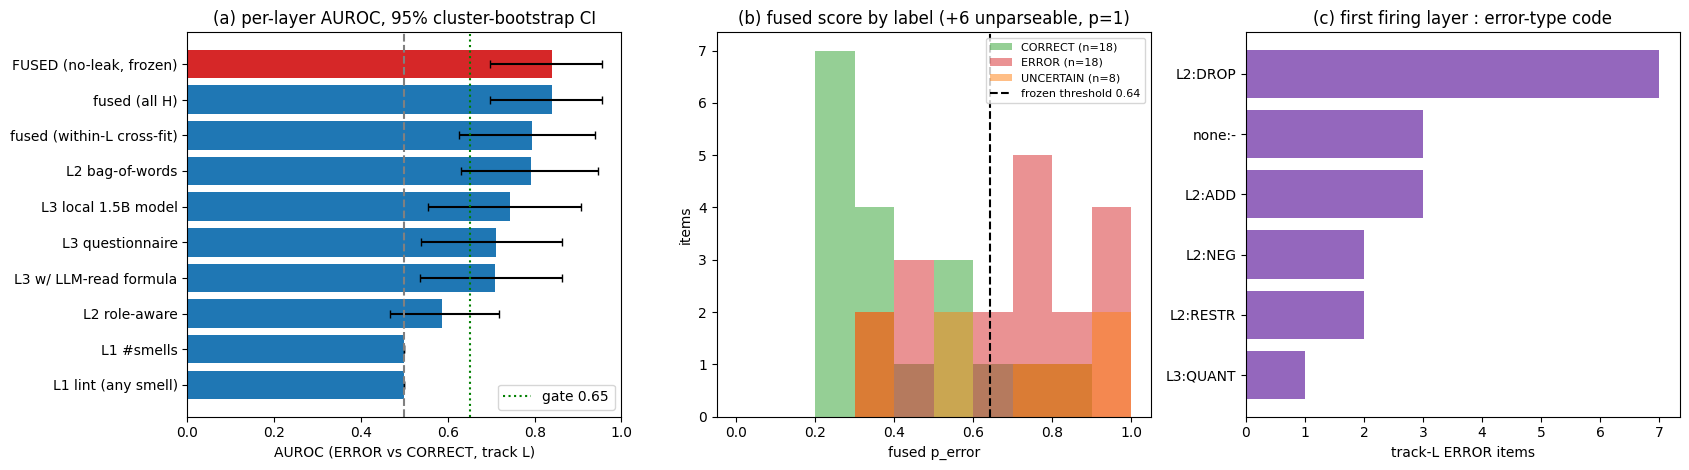

Example track-L ERROR items and what the checker says:
- p=1.00 fired=L2 code=ADD gold_class=ADD+DROP
    TEXT: Yale University has the largest university endowment of any educational institution.
    FOL : Uncertain
- p=1.00 fired=L2 code=ADD gold_class=ADD+DROP
    TEXT: Palace of Flies was translated from Italian.
    FOL : False
- p=0.97 fired=L2 code=ADD gold_class=ADD+DROP
    TEXT: Michael cannot block Windy's shooting.
    FOL : ¬(Jump(michael) ∧ Shooting(windy))
- p=0.93 fired=L2 code=DROP gold_class=ADD+DROP
    TEXT: Machine translation is a natural language processing task.
    FOL : MachineTranslation(machineTranslation)
- p=0.85 fired=L2 code=DROP gold_class=ADD+DROP
    TEXT: Bonnie performs in school talent shows often.
    FOL : Perform(bonnie)
- p=0.80 fired=L3 code=QUANT gold_class=ADD
    TEXT: Basque is not related to any other language.
    FOL : ¬∃x Related(basque, x)


In [24]:
per_item = [json.loads(l) for l in (RES / "per_item.jsonl").read_text().splitlines() if l.strip()]
Lr = [s for s in per_item if s["track"] == "L"]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

# (a) AUROC with CI per layer on the primary set
p = tab[(tab.set == prim) & tab.AUROC.notna()].sort_values("AUROC")
lo = [a - (c[0] if c and c[0] is not None else a) for a, c in zip(p.AUROC, p.CI95)]
hi = [(c[1] if c and c[1] is not None else a) - a for a, c in zip(p.AUROC, p.CI95)]
cols = ["#d62728" if "FUSED" in s else "#1f77b4" for s in p.score]
axes[0].barh(p.score, p.AUROC, xerr=[lo, hi], color=cols, capsize=3)
axes[0].axvline(0.5, ls="--", c="gray"); axes[0].axvline(0.65, ls=":", c="green", label="gate 0.65")
axes[0].set_xlim(0, 1); axes[0].set_xlabel("AUROC (ERROR vs CORRECT, track L)"); axes[0].legend(loc="lower right")
axes[0].set_title("(a) per-layer AUROC, 95% cluster-bootstrap CI")

# (b) fused score distribution by gold label (track L)
for lab, c in (("CORRECT", "#2ca02c"), ("ERROR", "#d62728"), ("UNCERTAIN", "#ff7f0e")):
    v = [s["p_fused_H"] for s in Lr if s["label"] == lab and s.get("parse_ok") and s.get("cpu_status") == "OK"]
    axes[1].hist(v, bins=np.linspace(0, 1, 11), alpha=0.5, color=c, label=f"{lab} (n={len(v)})")
axes[1].axvline(fused_thr_nl, c="k", ls="--", label=f"frozen threshold {fused_thr_nl:.2f}")
axes[1].set_xlabel("fused p_error"); axes[1].set_ylabel("items"); axes[1].legend(fontsize=8)
axes[1].set_title(f"(b) fused score by label (+{sum(1 for s in Lr if not s.get('parse_ok'))} unparseable, p=1)")

# (c) cascade: first-firing layer x error code on track-L ERROR items
err = [s for s in Lr if s["label"] == "ERROR"]
cnt = Counter((s["fired_layer"], s["error_code"] or "-") for s in err)
lbls = [f"{a}:{b}" for (a, b), _ in cnt.most_common()]
axes[2].barh(lbls[::-1], [n for _, n in cnt.most_common()][::-1], color="#9467bd")
axes[2].set_xlabel("track-L ERROR items"); axes[2].set_title("(c) first firing layer : error-type code")
plt.tight_layout(); plt.show()

print("Example track-L ERROR items and what the checker says:")
for s in sorted(err, key=lambda s: -s["p_fused_H"])[:6]:
    print(f"- p={s['p_fused_H']:.2f} fired={s['fired_layer']} code={s['error_code']} gold_class={s['auto_class']}\n"
          f"    TEXT: {s['text']}\n    FOL : {s['candidate_fol']}")